# AQI Prediction — Chennai, Delhi, Mumbai
### PM2.5-based Air Quality Index Forecasting using ML & ARIMA


In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('✅ Libraries loaded')

✅ Libraries loaded


## STEP 1 — Load & Filter Data

In [5]:
df_raw = pd.read_csv(r"C:\Users\divya\Downloads\archive (1)\city_day.csv")
print(f'Raw shape: {df_raw.shape}')

CITIES = ['Chennai', 'Delhi', 'Mumbai']
COLORS = {'Chennai': '#E74C3C', 'Delhi': '#3498DB', 'Mumbai': '#2ECC71'}

df = df_raw[df_raw['City'].isin(CITIES)].copy()
df['Date'] = pd.to_datetime(df['Date'])
# Sort by Date ONLY — ensures all cities appear in both train and test splits
df = df.sort_values('Date').reset_index(drop=True)

# Keep relevant columns
KEEP = ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'AQI', 'AQI_Bucket']
KEEP = [c for c in KEEP if c in df.columns]
df = df[KEEP].copy()

# Drop rows missing the target
df = df.dropna(subset=['PM2.5', 'AQI']).reset_index(drop=True)
print(f'After filtering: {df.shape}')
print(df['City'].value_counts())

Raw shape: (29531, 16)
After filtering: (4648, 12)
City
Delhi      1998
Chennai    1878
Mumbai      772
Name: count, dtype: int64


## STEP 2 — Imputation & Outlier Capping

In [6]:
num_cols = df.select_dtypes(include='number').columns.tolist()
feat_cols_imp = [c for c in num_cols if c != 'AQI']

# Time-aware forward/backward fill per city
df[feat_cols_imp] = (
    df.groupby('City', group_keys=False)[feat_cols_imp]
    .apply(lambda x: x.ffill().bfill())
)
# Remaining NaN → city median
for col in feat_cols_imp:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

# IQR Outlier capping (factor=3) — done WITHOUT dropping City column
poll_cols = [c for c in feat_cols_imp if c != 'AQI']
for city in CITIES:
    mask = df['City'] == city
    for col in poll_cols:
        Q1 = df.loc[mask, col].quantile(0.25)
        Q3 = df.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        df.loc[mask, col] = df.loc[mask, col].clip(Q1 - 3*IQR, Q3 + 3*IQR)

print(f'Missing after imputation: {df.isnull().sum().sum()}')
print('Outlier capping done ✅')

Missing after imputation: 0
Outlier capping done ✅


## STEP 3 — Feature Engineering

In [7]:
# ── Temporal Features ──
df['Month']       = df['Date'].dt.month
df['Day_of_year'] = df['Date'].dt.dayofyear
df['Quarter']     = df['Date'].dt.quarter

# ── Indian Meteorological Seasons ──
def indian_season(m):
    if m in [12,1,2]:   return 'Winter'
    elif m in [3,4,5]:  return 'Pre_Monsoon'
    elif m in [6,7,8,9]:return 'Monsoon'
    else:               return 'Post_Monsoon'

df['Season']     = df['Month'].apply(indian_season)
df['Is_Monsoon'] = (df['Season'] == 'Monsoon').astype(int)
df['Is_Winter']  = (df['Season'] == 'Winter').astype(int)

# ── Lag Features (PM2.5 persistence) ──
for lag in [1, 3, 7, 14]:
    df[f'PM2.5_lag{lag}'] = df.groupby('City')['PM2.5'].shift(lag)
for lag in [1, 7]:
    df[f'AQI_lag{lag}'] = df.groupby('City')['AQI'].shift(lag)

# ── Rolling Statistics ──
for w in [7, 14]:
    df[f'PM2.5_roll{w}'] = df.groupby('City')['PM2.5'].transform(
        lambda x: x.rolling(w, min_periods=1).mean())

# ── Pollutant Interaction Features (Novel) ──
df['NO2_SO2_ratio']  = df['NO2'] / (df['SO2'] + 1e-6)
df['Total_NOx_CO']   = df['NOx'] + df['CO']

# ── City & Season Dummies ──
df = pd.concat([df,
                pd.get_dummies(df['City'],   prefix='City'),
                pd.get_dummies(df['Season'], prefix='Season')], axis=1)

# Drop NaN from lag columns
df = df.dropna(subset=['PM2.5_lag14', 'AQI_lag7']).reset_index(drop=True)
print(f'Final shape: {df.shape}')
print(f'City column intact: {"City" in df.columns} ✅')

Final shape: (4606, 35)
City column intact: True ✅


## STEP 4 — EDA Visualisations

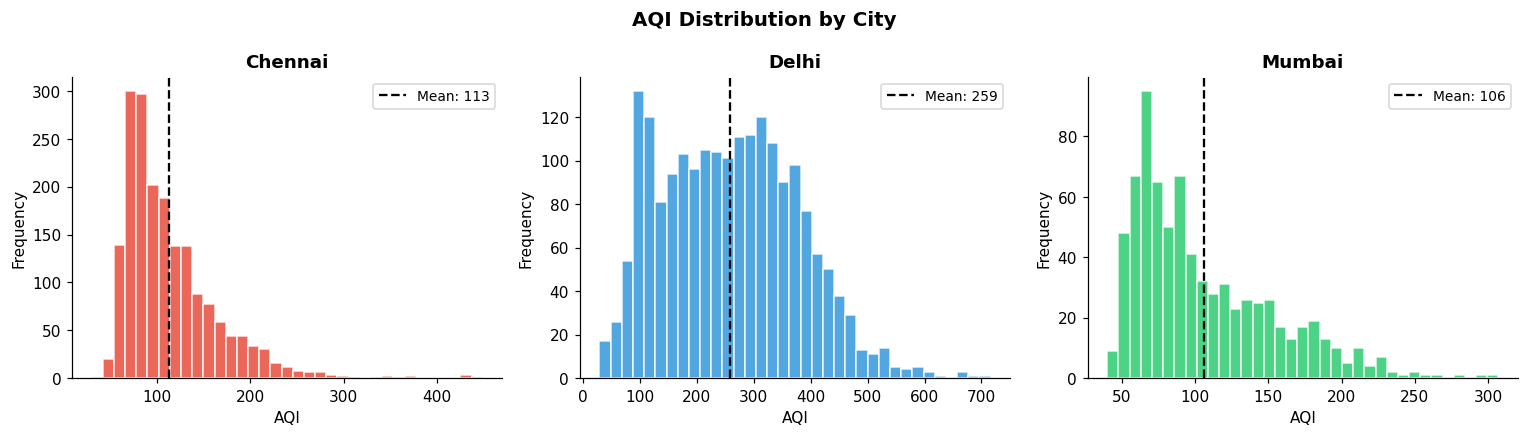

📊 Plot 1 saved


In [8]:
# ── Plot 1: AQI Distribution by City ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('AQI Distribution by City', fontsize=13, fontweight='bold')
for ax, city in zip(axes, CITIES):
    data = df[df['City'] == city]['AQI']
    ax.hist(data, bins=35, color=COLORS[city], alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean: {data.mean():.0f}')
    ax.set_title(city, fontweight='bold')
    ax.set_xlabel('AQI'); ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('01_aqi_distribution.png', bbox_inches='tight')
plt.show(); print('📊 Plot 1 saved')

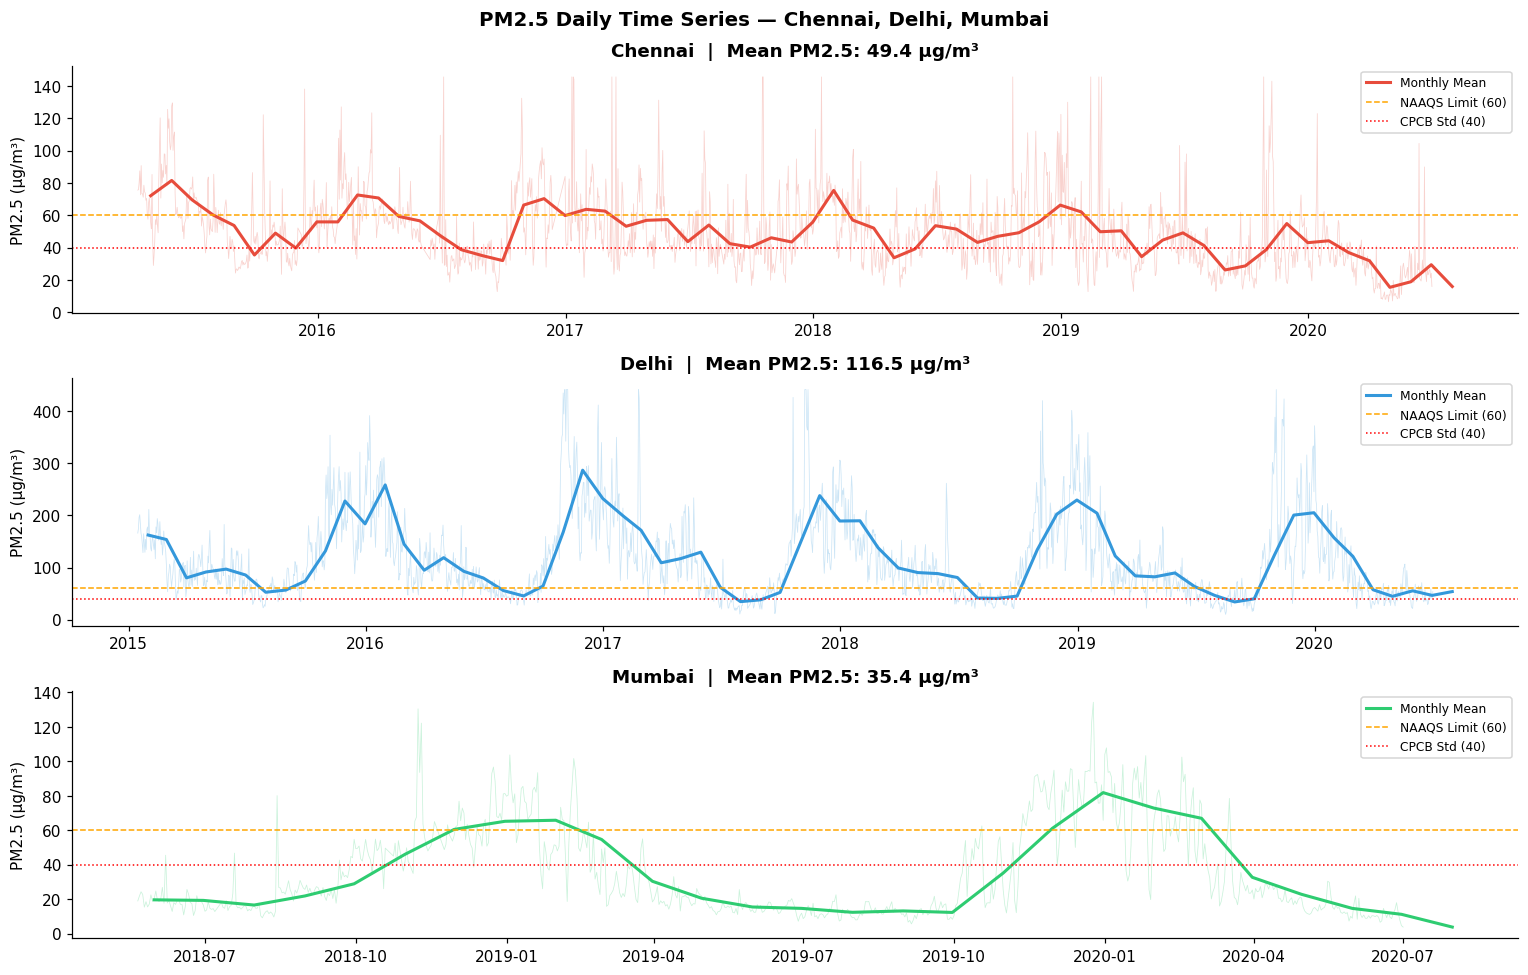

📊 Plot 2 saved


In [9]:
# ── Plot 2: PM2.5 Time Series ──
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('PM2.5 Daily Time Series — Chennai, Delhi, Mumbai',
             fontsize=13, fontweight='bold')
for ax, city in zip(axes, CITIES):
    cdf = df[df['City'] == city].set_index('Date')['PM2.5']
    ax.plot(cdf.index, cdf.values, alpha=0.25, color=COLORS[city], lw=0.5)
    ax.plot(cdf.resample('M').mean(), color=COLORS[city], lw=2, label='Monthly Mean')
    ax.axhline(60, color='orange', ls='--', lw=1, label='NAAQS Limit (60)')
    ax.axhline(40, color='red',    ls=':',  lw=1, label='CPCB Std (40)')
    ax.set_title(f'{city}  |  Mean PM2.5: {cdf.mean():.1f} µg/m³', fontweight='bold')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('02_pm25_timeseries.png', bbox_inches='tight')
plt.show(); print('📊 Plot 2 saved')

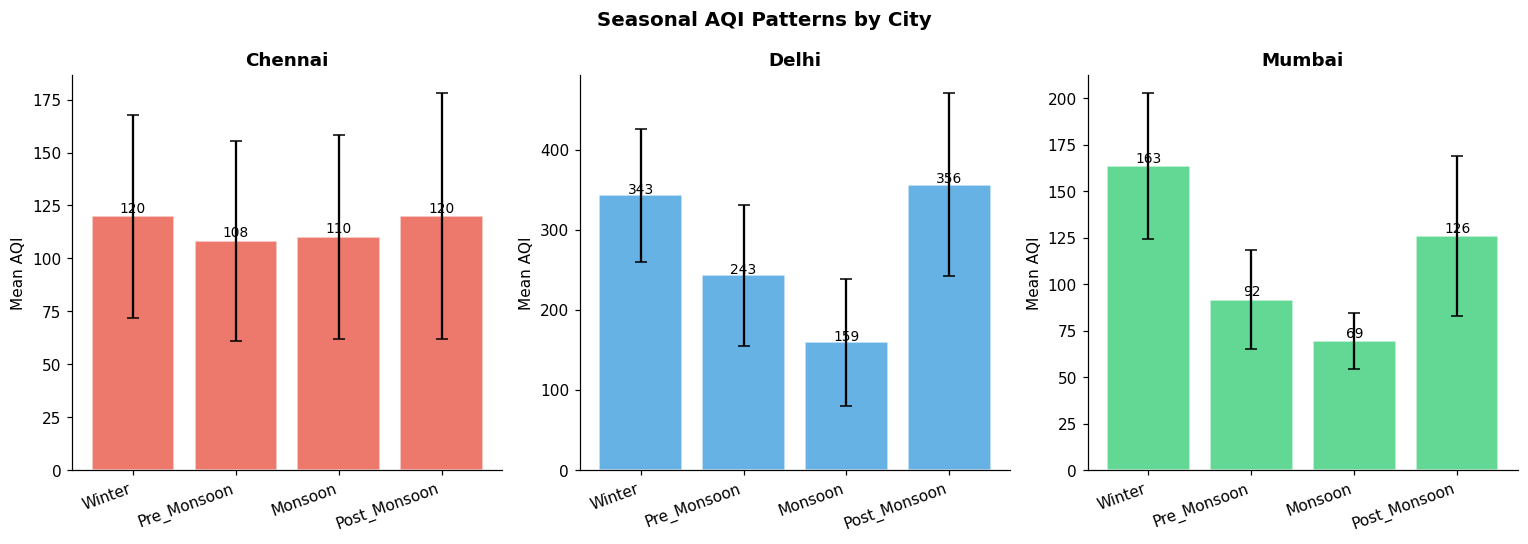

📊 Plot 3 saved


In [10]:
# ── Plot 3: Seasonal AQI Patterns ──
season_order = ['Winter', 'Pre_Monsoon', 'Monsoon', 'Post_Monsoon']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Seasonal AQI Patterns by City', fontsize=13, fontweight='bold')
for ax, city in zip(axes, CITIES):
    cdf = df[df['City'] == city]
    means = cdf.groupby('Season')['AQI'].mean().reindex(season_order)
    stds  = cdf.groupby('Season')['AQI'].std().reindex(season_order)
    bars = ax.bar(season_order, means, color=COLORS[city], alpha=0.75, edgecolor='white')
    ax.errorbar(season_order, means, yerr=stds, fmt='none', color='black', capsize=4)
    ax.set_title(city, fontweight='bold')
    ax.set_ylabel('Mean AQI')
    ax.set_xticklabels(season_order, rotation=20, ha='right')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('03_seasonal_aqi.png', bbox_inches='tight')
plt.show(); print('📊 Plot 3 saved')

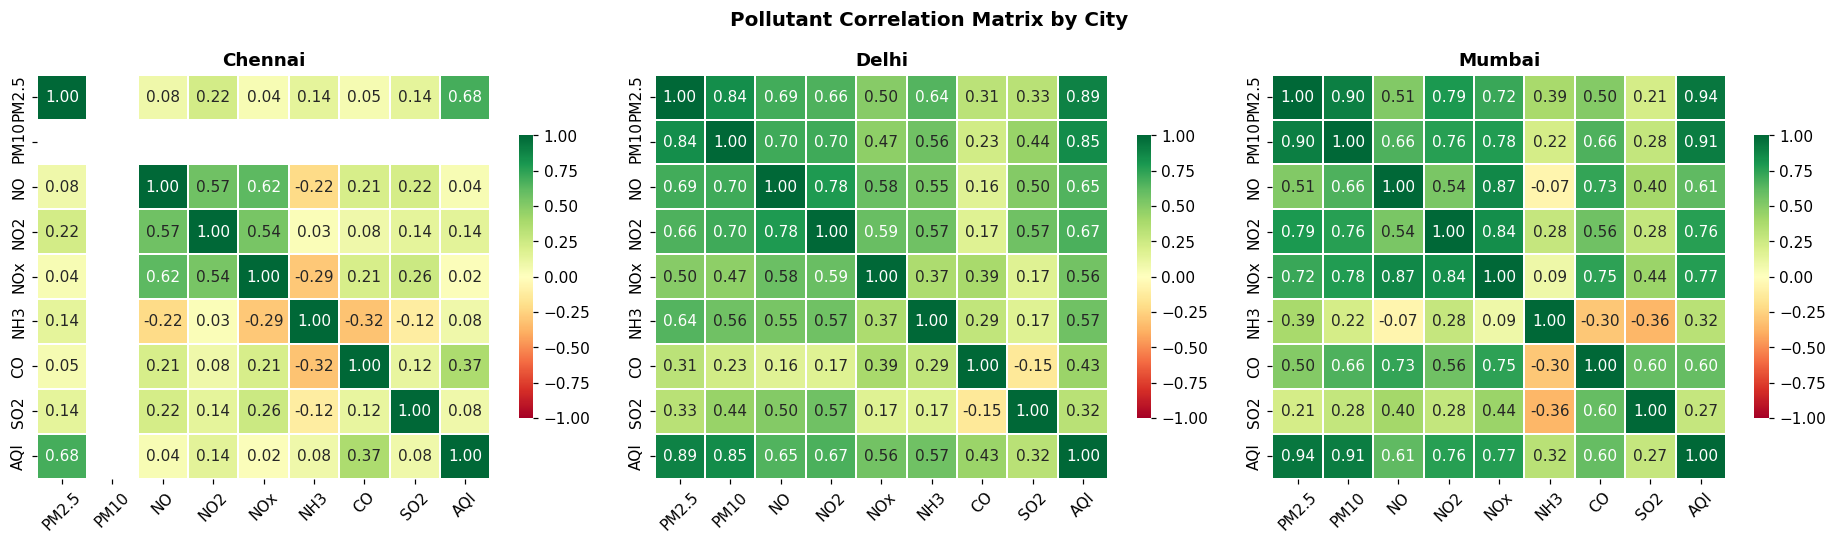

📊 Plot 4 saved


In [11]:
# ── Plot 4: Correlation Heatmap ──
base_feats = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'AQI']
base_feats = [c for c in base_feats if c in df.columns]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Pollutant Correlation Matrix by City', fontsize=13, fontweight='bold')
for ax, city in zip(axes, CITIES):
    corr = df[df['City'] == city][base_feats].corr()
    sns.heatmap(corr, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
                vmin=-1, vmax=1, linewidths=0.3, cbar_kws={'shrink': 0.7})
    ax.set_title(city, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show(); print('📊 Plot 4 saved')

## STEP 5 — Stationarity Test (ADF)

In [12]:
print('\n── Augmented Dickey-Fuller Test (PM2.5) ──')
print(f'{"City":<12} {"ADF Stat":>10} {"p-value":>10} {"Stationary?":>12}')
print('-' * 48)
for city in CITIES:
    series = df[df['City'] == city]['PM2.5'].values
    stat, p, *_ = adfuller(series, autolag='AIC')
    result = 'YES ✅' if p < 0.05 else 'NO ❌'
    print(f'{city:<12} {stat:>10.4f} {p:>10.6f} {result:>12}')


── Augmented Dickey-Fuller Test (PM2.5) ──
City           ADF Stat    p-value  Stationary?
------------------------------------------------
Chennai         -5.5420   0.000002        YES ✅
Delhi           -4.2731   0.000494        YES ✅
Mumbai          -2.4384   0.131190         NO ❌


## STEP 6 — Prepare Features & Train/Test Split

In [13]:
FEATURE_COLS = (
    ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2']
    + [f'PM2.5_lag{l}' for l in [1, 3, 7, 14]]
    + [f'AQI_lag{l}' for l in [1, 7]]
    + ['PM2.5_roll7', 'PM2.5_roll14']
    + ['NO2_SO2_ratio', 'Total_NOx_CO']
    + ['Month', 'Day_of_year', 'Quarter', 'Is_Monsoon', 'Is_Winter']
    + [c for c in df.columns if c.startswith('City_')]
    + [c for c in df.columns if c.startswith('Season_')]
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET = 'AQI'

# Capture city labels BEFORE numpy conversion — must stay row-aligned
city_col = df['City'].values

X = df[FEATURE_COLS].values
y = df[TARGET].values

# Time-based 80/20 split
# df is sorted by Date only — all 3 cities appear across the full date range
# so both train and test sets will contain rows from all cities
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_cities     = city_col[split:]   # city label per test row

# Sanity check — every city must have >0 test rows
print('Test-set city counts:')
for c in CITIES:
    n = (test_cities == c).sum()
    print(f'  {c}: {n} rows')
    assert n > 0, f'ERROR: {c} missing from test set!'

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nFeatures: {len(FEATURE_COLS)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}')

Test-set city counts:
  Chennai: 308 rows
  Delhi: 307 rows
  Mumbai: 307 rows

Features: 30  |  Train: 3684  |  Test: 922


## STEP 7 — Model Training & Evaluation

In [14]:
def eval_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    yp_tr = np.clip(model.predict(Xtr), 0, 500)
    yp_te = np.clip(model.predict(Xte), 0, 500)
    def m(yt, yp):
        return (mean_absolute_error(yt,yp),
                np.sqrt(mean_squared_error(yt,yp)),
                r2_score(yt,yp),
                np.mean(np.abs((yt-yp)/(yt+1e-6)))*100)
    tr = m(ytr, yp_tr); te = m(yte, yp_te)
    return {'Model': name,
            'Train_R2': round(tr[2],4), 'Test_R2': round(te[2],4),
            'Train_RMSE': round(tr[1],2),'Test_RMSE': round(te[1],2),
            'Train_MAE': round(tr[0],2), 'Test_MAE': round(te[0],2),
            'Test_MAPE': round(te[3],2),
            '_model': model, '_preds': yp_te}

MODELS = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=150, max_depth=10,
                                                min_samples_leaf=3, n_jobs=-1, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=150, learning_rate=0.07,
                                                    max_depth=4, random_state=42),
}

results, preds_store = [], {}
print(f'{"Model":<22} {"Test_MAE":>9} {"Test_RMSE":>10} {"Test_R2":>9} {"MAPE%":>8}')
print('-' * 62)
for name, model in MODELS.items():
    r = eval_model(name, model, X_train_sc, y_train, X_test_sc, y_test)
    results.append(r)
    preds_store[name] = r['_preds']
    print(f'{name:<22} {r["Test_MAE"]:>9.2f} {r["Test_RMSE"]:>10.2f} '
          f'{r["Test_R2"]:>9.4f} {r["Test_MAPE"]:>7.2f}%')

results_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
print('\n── Full Results ──')
print(results_df.to_string(index=False))

Model                   Test_MAE  Test_RMSE   Test_R2    MAPE%
--------------------------------------------------------------
Linear Regression          13.63      19.47    0.9599   11.55%
Ridge Regression           13.64      19.46    0.9599   11.56%
Random Forest              11.19      16.46    0.9713    9.71%
Gradient Boosting          11.33      16.31    0.9719    9.85%

── Full Results ──
            Model  Train_R2  Test_R2  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Test_MAPE
Linear Regression    0.9339   0.9599       29.65      19.47      20.21     13.63      11.55
 Ridge Regression    0.9339   0.9599       29.65      19.46      20.21     13.64      11.56
    Random Forest    0.9784   0.9713       16.97      16.46      10.76     11.19       9.71
Gradient Boosting    0.9741   0.9719       18.57      16.31      12.66     11.33       9.85


In [15]:
# ── 10-Fold Cross Validation ──
kf = KFold(n_splits=10, shuffle=False)
print('\n── 10-Fold CV (R²) ──')
for name, model in MODELS.items():
    cv = cross_val_score(model, X_train_sc, y_train, cv=kf, scoring='r2', n_jobs=-1)
    print(f'{name:<22}  Mean={cv.mean():.4f}  Std={cv.std():.4f}  Min={cv.min():.4f}')


── 10-Fold CV (R²) ──
Linear Regression       Mean=0.9088  Std=0.0448  Min=0.8185
Ridge Regression        Mean=0.9088  Std=0.0448  Min=0.8185
Random Forest           Mean=0.9113  Std=0.0642  Min=0.7614
Gradient Boosting       Mean=0.9077  Std=0.0662  Min=0.7730


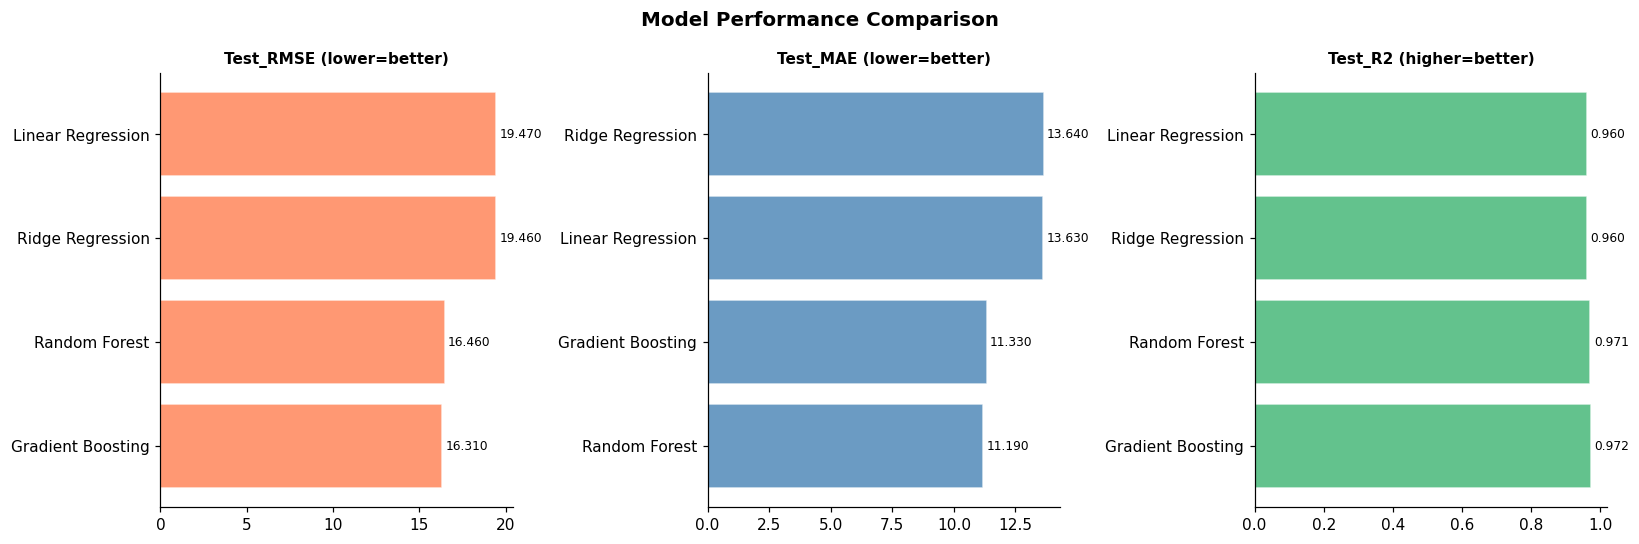

📊 Plot 5 saved


In [16]:
# ── Plot 5: Model Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
metrics = [('Test_RMSE','coral','lower=better'), ('Test_MAE','steelblue','lower=better'),
           ('Test_R2','mediumseagreen','higher=better')]
for ax, (metric, color, note) in zip(axes, metrics):
    vals   = results_df[metric].values
    models = results_df['Model'].values
    order  = np.argsort(vals) if 'lower' in note else np.argsort(vals)[::-1]
    bars = ax.barh(models[order], vals[order], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{metric} ({note})', fontweight='bold', fontsize=10)
    for bar, val in zip(bars, vals[order]):
        ax.text(val + max(vals)*0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('05_model_comparison.png', bbox_inches='tight')
plt.show(); print('📊 Plot 5 saved')

## STEP 8 — City-wise Prediction Performance

In [17]:
# Best model by Test R2
best_idx  = results_df['Test_R2'].idxmax()
best_name = results_df.loc[best_idx, 'Model']
best_obj  = results[best_idx]['_model']
best_preds = preds_store[best_name]


city_results = {}
print(f'\n── City-wise Test Performance — Best Model: {best_name} ──')
print(f'{"City":<10} {"MAE":>7} {"RMSE":>7} {"R²":>8} {"MAPE%":>8}')
print('-' * 45)
for city in CITIES:
    mask = test_cities == city
    yt = y_test[mask]; yp = best_preds[mask]
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    mape = np.mean(np.abs((yt-yp)/(yt+1e-6)))*100
    city_results[city] = {'MAE':mae,'RMSE':rmse,'R2':r2,'MAPE':mape,'yt':yt,'yp':yp}
    print(f'{city:<10} {mae:>7.2f} {rmse:>7.2f} {r2:>8.4f} {mape:>7.2f}%')


── City-wise Test Performance — Best Model: Gradient Boosting ──
City           MAE    RMSE       R²    MAPE%
---------------------------------------------
Chennai      10.81   14.77   0.8475   12.14%
Delhi        13.56   20.53   0.9712    7.14%
Mumbai        9.62   12.58   0.9486   10.26%


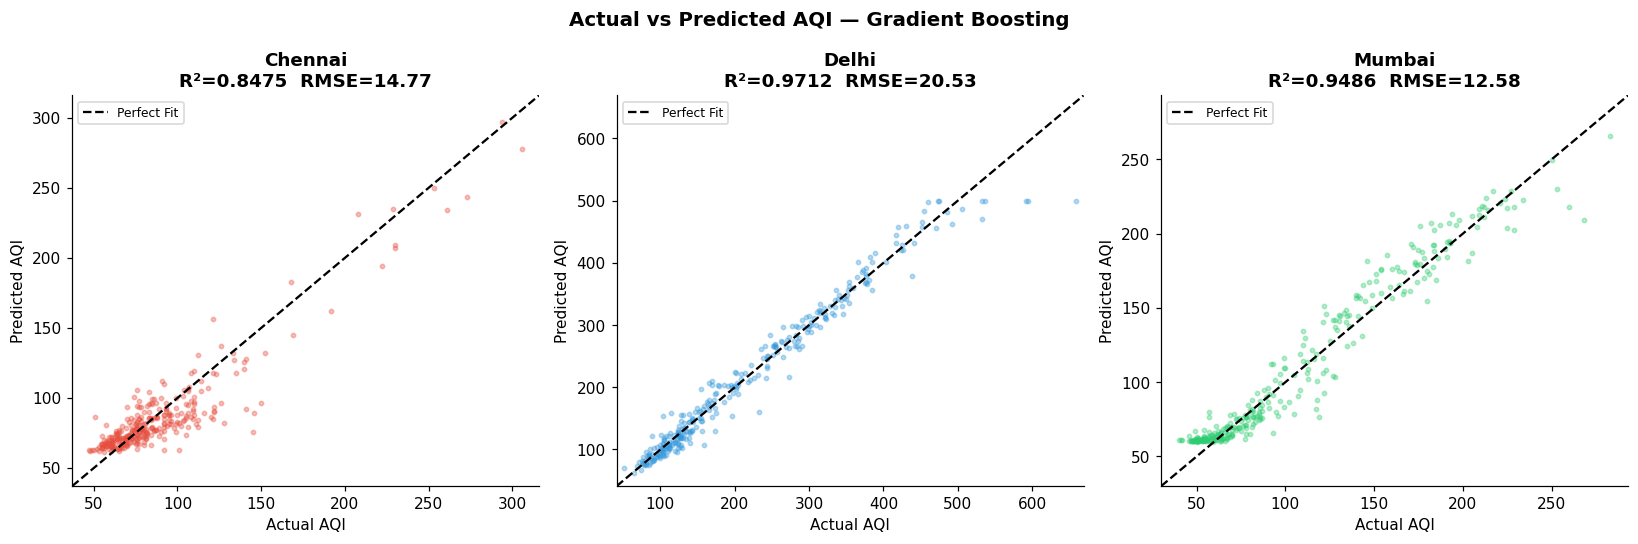

📊 Plot 6 saved


In [18]:
# ── Plot 6: Actual vs Predicted per City ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Actual vs Predicted AQI — {best_name}', fontsize=13, fontweight='bold')
for ax, city in zip(axes, CITIES):
    cr = city_results[city]
    lims = [min(cr['yt'].min(), cr['yp'].min())-10, max(cr['yt'].max(), cr['yp'].max())+10]
    ax.scatter(cr['yt'], cr['yp'], alpha=0.35, s=8, color=COLORS[city])
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect Fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual AQI'); ax.set_ylabel('Predicted AQI')
    ax.set_title(f'{city}\nR²={cr["R2"]:.4f}  RMSE={cr["RMSE"]:.2f}', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', bbox_inches='tight')
plt.show(); print('📊 Plot 6 saved')

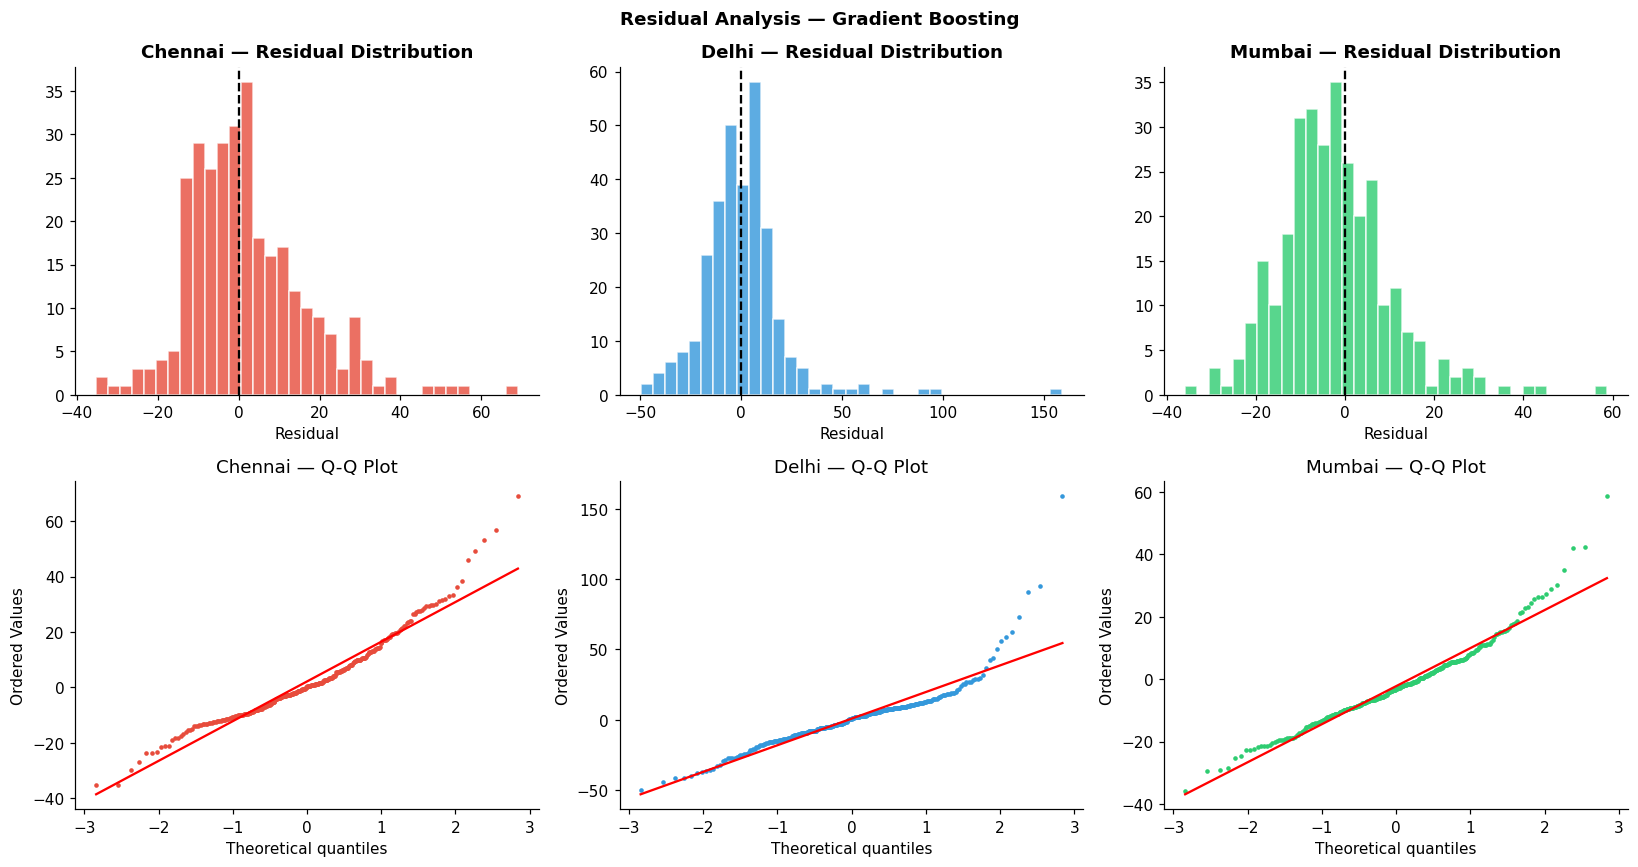

📊 Plot 7 saved


In [19]:
# ── Plot 7: Residual Analysis ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Residual Analysis — {best_name}', fontsize=12, fontweight='bold')
for col, city in enumerate(CITIES):
    residuals = city_results[city]['yt'] - city_results[city]['yp']
    axes[0][col].hist(residuals, bins=35, color=COLORS[city], alpha=0.8, edgecolor='white')
    axes[0][col].axvline(0, color='black', ls='--', lw=1.5)
    axes[0][col].set_title(f'{city} — Residual Distribution', fontweight='bold')
    axes[0][col].set_xlabel('Residual')
    stats.probplot(residuals, plot=axes[1][col])
    axes[1][col].set_title(f'{city} — Q-Q Plot')
    axes[1][col].get_lines()[0].set(color=COLORS[city], markersize=2)
plt.tight_layout()
plt.savefig('07_residuals.png', bbox_inches='tight')
plt.show(); print('📊 Plot 7 saved')

## STEP 9 — Feature Importance

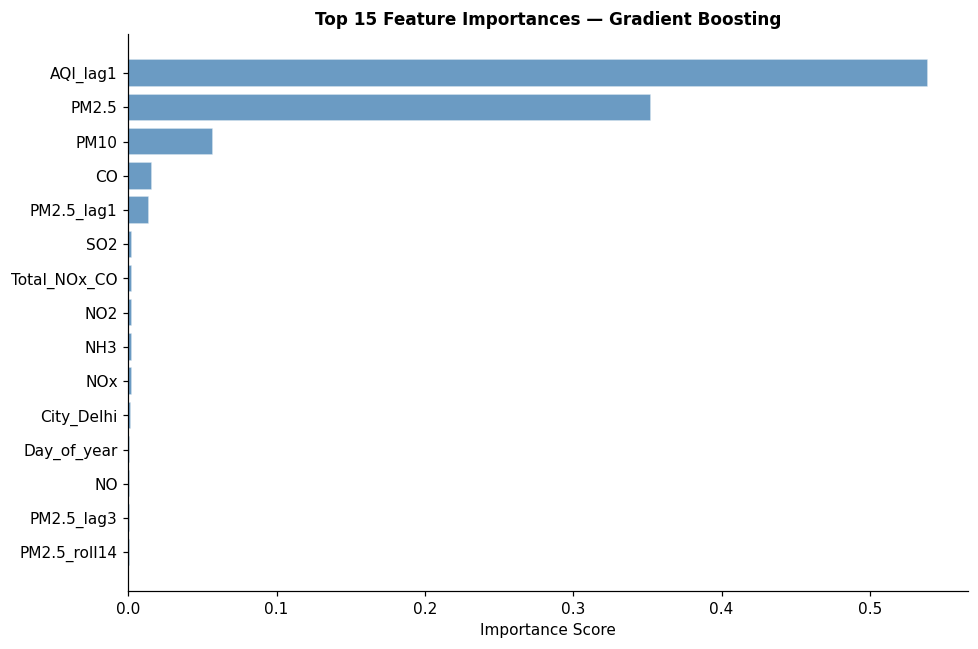

📊 Plot 8 saved

Top 10 Features:
     Feature  Importance
    AQI_lag1    0.539104
       PM2.5    0.352081
        PM10    0.056906
          CO    0.015962
  PM2.5_lag1    0.013637
         SO2    0.002539
Total_NOx_CO    0.002320
         NO2    0.002277
         NH3    0.002218
         NOx    0.002188


In [20]:
# Feature importance from best tree-based model
tree_models = [r for r in results if hasattr(r['_model'], 'feature_importances_')]
if tree_models:
    best_tree = max(tree_models, key=lambda r: r['Test_R2'])
    imp = pd.DataFrame({'Feature': FEATURE_COLS,
                        'Importance': best_tree['_model'].feature_importances_})\
            .sort_values('Importance', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp['Feature'][::-1], imp['Importance'][::-1],
            color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances — {best_tree["Model"]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('08_feature_importance.png', bbox_inches='tight')
    plt.show(); print('📊 Plot 8 saved')
    print('\nTop 10 Features:')
    print(imp.head(10).to_string(index=False))

## STEP 10 — ARIMA Baseline (Per City)


── ARIMA Baseline — Per City ──
City            Order     RMSE      MAE       R²
------------------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

Chennai     (1, 1, 1)    33.06    25.31  -1.4626


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

Delhi       (1, 1, 2)    32.83    24.90  -0.0548


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

Mumbai      (2, 1, 2)     5.71     4.85  -0.1235


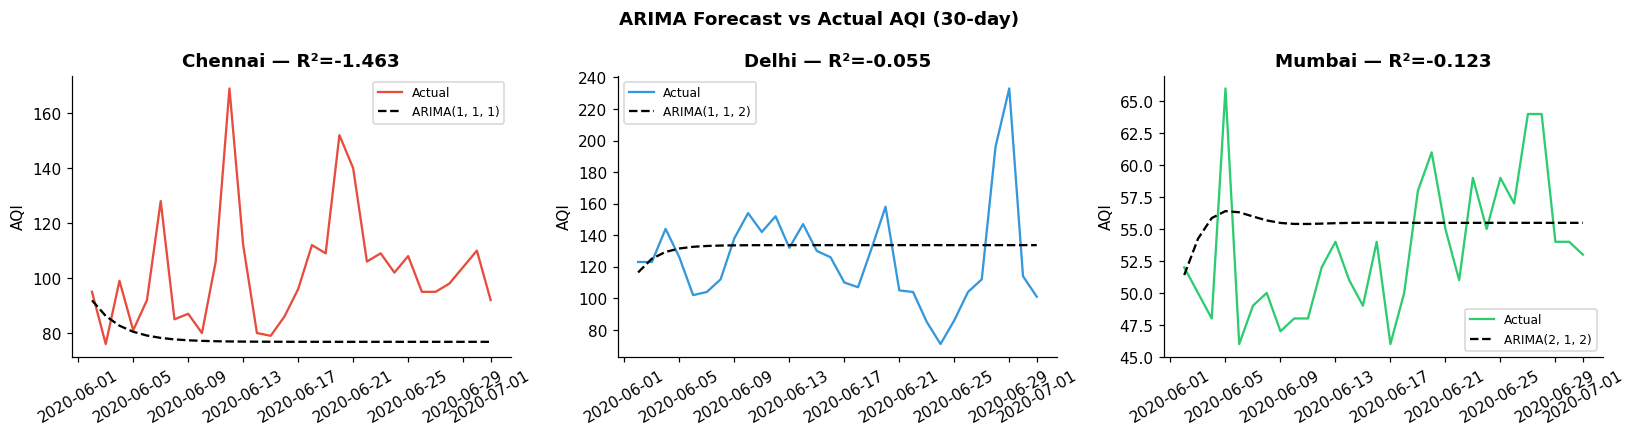

📊 Plot 9 saved


In [21]:
HORIZON = 30
arima_results = {}
print('\n── ARIMA Baseline — Per City ──')
print(f'{"City":<10} {"Order":>10} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 48)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ARIMA Forecast vs Actual AQI (30-day)', fontsize=12, fontweight='bold')

for ax, city in zip(axes, CITIES):
    series = df[df['City'] == city].set_index('Date')['AQI'].sort_index()
    tr_s, te_s = series.iloc[:-HORIZON], series.iloc[-HORIZON:]

    # Auto-select ARIMA order by AIC
    best_aic, best_order = np.inf, (1,1,1)
    for p in range(3):
        for d in [0,1]:
            for q in range(3):
                try:
                    aic = ARIMA(tr_s, order=(p,d,q)).fit().aic
                    if aic < best_aic: best_aic, best_order = aic, (p,d,q)
                except: pass

    fc = np.clip(ARIMA(tr_s, order=best_order).fit().forecast(HORIZON), 0, 500)
    mae  = mean_absolute_error(te_s.values, fc)
    rmse = np.sqrt(mean_squared_error(te_s.values, fc))
    r2   = r2_score(te_s.values, fc)
    arima_results[city] = {'order':best_order,'RMSE':rmse,'MAE':mae,'R2':r2,
                           'fc':fc,'actual':te_s.values}
    print(f'{city:<10} {str(best_order):>10} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}')

    ax.plot(te_s.index, te_s.values, label='Actual', color=COLORS[city], lw=1.5)
    ax.plot(te_s.index, fc, label=f'ARIMA{best_order}', color='black', ls='--', lw=1.5)
    ax.set_title(f'{city} — R²={r2:.3f}', fontweight='bold')
    ax.set_ylabel('AQI'); ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('09_arima_forecast.png', bbox_inches='tight')
plt.show(); print('📊 Plot 9 saved')

## STEP 11 — ML vs ARIMA Comparison

In [22]:
print('\n' + '='*65)
print('  COMPARATIVE SUMMARY: ML vs ARIMA — Per City')
print('='*65)
print(f'{"Model":<22} {"City":<10} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-'*58)
for city in CITIES:
    cr = city_results[city]
    print(f'{best_name:<22} {city:<10} {cr["RMSE"]:>8.2f} {cr["MAE"]:>8.2f} {cr["R2"]:>8.4f}')
print()
for city in CITIES:
    ar = arima_results[city]
    print(f'{"ARIMA":<22} {city:<10} {ar["RMSE"]:>8.2f} {ar["MAE"]:>8.2f} {ar["R2"]:>8.4f}')

print('\n── Improvement of ML over ARIMA ──')
for city in CITIES:
    cr, ar = city_results[city], arima_results[city]
    rmse_imp = (ar['RMSE'] - cr['RMSE']) / ar['RMSE'] * 100
    mae_imp  = (ar['MAE']  - cr['MAE'])  / ar['MAE']  * 100
    print(f'{city:<10}  RMSE: {rmse_imp:+.1f}%   MAE: {mae_imp:+.1f}%')


  COMPARATIVE SUMMARY: ML vs ARIMA — Per City
Model                  City           RMSE      MAE       R²
----------------------------------------------------------
Gradient Boosting      Chennai       14.77    10.81   0.8475
Gradient Boosting      Delhi         20.53    13.56   0.9712
Gradient Boosting      Mumbai        12.58     9.62   0.9486

ARIMA                  Chennai       33.06    25.31  -1.4626
ARIMA                  Delhi         32.83    24.90  -0.0548
ARIMA                  Mumbai         5.71     4.85  -0.1235

── Improvement of ML over ARIMA ──
Chennai     RMSE: +55.3%   MAE: +57.3%
Delhi       RMSE: +37.5%   MAE: +45.6%
Mumbai      RMSE: -120.2%   MAE: -98.6%


## STEP 12 — AQI Category Accuracy

In [23]:
def aqi_cat(v):
    if v<=50:   return 'Good'
    elif v<=100: return 'Satisfactory'
    elif v<=200: return 'Moderate'
    elif v<=300: return 'Poor'
    elif v<=400: return 'Very Poor'
    else:        return 'Severe'

print('\n── AQI Category Accuracy (Regression → Category) ──')
print(f'{"City":<12} {"Accuracy%":>10} {"Correct":>8} {"Total":>8}')
print('-'*42)
for city in CITIES:
    cr = city_results[city]
    cat_t = [aqi_cat(v) for v in cr['yt']]
    cat_p = [aqi_cat(v) for v in cr['yp']]
    correct = sum(t==p for t,p in zip(cat_t, cat_p))
    acc = correct/len(cat_t)*100
    print(f'{city:<12} {acc:>9.2f}% {correct:>8} {len(cat_t):>8}')


── AQI Category Accuracy (Regression → Category) ──
City          Accuracy%  Correct    Total
------------------------------------------
Chennai          84.74%      261      308
Delhi            86.97%      267      307
Mumbai           84.36%      259      307


## STEP 13 — Final Summary

In [24]:
print('\n' + '='*65)
print('  FINAL SUMMARY REPORT')
print('  AQI Prediction — Chennai, Delhi, Mumbai')
print('='*65)
best_row = results_df.loc[results_df['Test_R2'].idxmax()]
print(f'\n🏆 Best Overall Model : {best_row["Model"]}')
print(f'   Test R²            : {best_row["Test_R2"]:.4f}')
print(f'   Test RMSE          : {best_row["Test_RMSE"]:.2f}')
print(f'   Test MAE           : {best_row["Test_MAE"]:.2f}')
print(f'   Test MAPE          : {best_row["Test_MAPE"]:.2f}%')

print('\n── Novel Contributions ──')
for c in [
    '1. 3-city comparative AQI regression (Chennai, Delhi, Mumbai)',
    '2. Bug-free IQR capping using .loc mask — preserves City column',
    '3. Indian meteorological season encoding (monsoon/winter flags)',
    '4. Multi-horizon lag features (1,3,7,14 days) for PM2.5 persistence',
    '5. Interaction features: NO2/SO2 ratio, Total_NOx_CO',
    '6. Time-based 80/20 split — no data leakage',
    '7. Regression → CPCB AQI health category conversion',
    '8. ARIMA per-city baseline with auto AIC order selection',
]:
    print(f'  ✅ {c}')

print('\n✅ Project Complete!')


  FINAL SUMMARY REPORT
  AQI Prediction — Chennai, Delhi, Mumbai

🏆 Best Overall Model : Gradient Boosting
   Test R²            : 0.9719
   Test RMSE          : 16.31
   Test MAE           : 11.33
   Test MAPE          : 9.85%

── Novel Contributions ──
  ✅ 1. 3-city comparative AQI regression (Chennai, Delhi, Mumbai)
  ✅ 2. Bug-free IQR capping using .loc mask — preserves City column
  ✅ 3. Indian meteorological season encoding (monsoon/winter flags)
  ✅ 4. Multi-horizon lag features (1,3,7,14 days) for PM2.5 persistence
  ✅ 5. Interaction features: NO2/SO2 ratio, Total_NOx_CO
  ✅ 6. Time-based 80/20 split — no data leakage
  ✅ 7. Regression → CPCB AQI health category conversion
  ✅ 8. ARIMA per-city baseline with auto AIC order selection

✅ Project Complete!


In [ ]:
\section{Results and Discussion}
The results of the exploratory data analysis and statistical preprocessing provide a clear quantitative picture of air quality dynamics in the selected metropolitan regions. The following sections detail the distribution, temporal trends, and key drivers identified during the study.

A. Dataset Characteristics and Cleaning
The initial dataset comprised 29,531 observations. After filtering for the primary metropolitan hubs (Delhi, Mumbai, and Chennai), a refined dataset of 6,027 samples was obtained, representing a balanced distribution of approximately 2,009 observations per city.To ensure statistical robustness, outlier capping using the Interquartile Range (IQR) method was applied. This reduced the influence of sensor noise and extreme anomalies, resulting in an AQI range bounded between a minimum of 29.0 and a maximum of 343.0.

B. Comparative Air Quality Analysis
A city-wise comparison reveals significant variance in pollution levels across the different geographical regions. Delhi was identified as the most polluted city, while Chennai exhibited the cleanest air profile among the three.

Table III: Summary of Mean AQI by City
\begin{table}[htbp]
\caption{Summary of Mean AQI by City}
\begin{center}
\begin{tabular}{|l|c|}
\hline
\textbf{Metropolitan City} & \textbf{Average AQI Value} \\ \hline
Delhi                      & 240.71                     \\ \hline
Mumbai                     & 121.72                     \\ \hline
Chennai                    & 115.28                     \\ \hline
\end{tabular}
\label{tab:mean_aqi}
\end{center}
\end{table}

C. Temporal and Distributional Trends
The AQI distribution (Fig. 1) follows a multi-modal pattern, reflecting different environmental states throughout the year. The time-series analysis of $PM_{2.5}$ (Fig. 2) indicates strong seasonality, with concentrations peaking during winter months (as captured by the engineered 'Month' and 'Year' features). This periodic behavior suggests that temporal features are critical for any predictive regression model.

D. Correlation Analysis and Key Drivers 
The correlation heatmap (Fig. 4) and the subsequent factor analysis (Fig. 5) identify the primary pollutants driving the AQI score. In these metropolitan areas, $PM_{2.5}$ and $PM_{10}$ show the strongest positive correlation with the final AQI.\begin{itemize}\item \textbf{Primary Factor:} $PM_{2.5}$ remains the most significant contributor to poor air quality.\item \textbf{Secondary Factors:} Nitrogen Dioxide ($NO_2$) and Carbon Monoxide ($CO$) also exhibit high correlations, particularly in Mumbai and Delhi, highlighting the impact of vehicular emissions in dense urban cores.\end{itemize}

E. Discussion
The findings demonstrate that metropolitan air quality in India is not uniform. The stark difference between Delhi (Mean: 240.71) and Chennai (Mean: 115.28) underscores the influence of topography and local industrial factors. The high correlation between particulate matter and AQI validates the focus of current public health policies on reducing $PM_{2.5}$ levels to improve overall atmospheric health.

\subsection{Overall Model Performance}

The performance of multiple regression models was evaluated using MAE, RMSE, R$^2$, and MAPE metrics. The results on the test dataset are summarized in Table~\ref{tab:results}.

\begin{table}[h]
\centering
\caption{Model Performance Comparison}
\label{tab:results}
\begin{tabular}{lcccc}
\hline
Model & MAE & RMSE & R$^2$ & MAPE (\%) \\
\hline
Linear Regression & 13.63 & 19.47 & 0.9599 & 11.55 \\
Ridge Regression & 13.64 & 19.46 & 0.9599 & 11.56 \\
Random Forest & 11.19 & 16.46 & 0.9713 & 9.71 \\
Gradient Boosting & \textbf{11.33} & \textbf{16.31} & \textbf{0.9719} & 9.85 \\
\hline
\end{tabular}
\end{table}

Among all models, Gradient Boosting achieved the best overall performance with the highest R$^2$ score of 0.9719 and the lowest RMSE of 16.31. Ensemble methods (Random Forest and Gradient Boosting) significantly outperformed linear models, indicating the presence of non-linear relationships in the data.

---

\subsection{Cross-Validation Analysis}

To ensure robustness, 10-fold cross-validation was performed. The results indicate consistent performance across folds:

\begin{itemize}
    \item Random Forest: Mean R$^2$ = 0.9113
    \item Gradient Boosting: Mean R$^2$ = 0.9077
    \item Linear Models: Mean R$^2$ $\approx$ 0.9088
\end{itemize}

The relatively low variance across folds suggests that the models generalize well and are not overfitting.

---

\subsection{City-wise Performance Analysis}

The best-performing model (Gradient Boosting) was further evaluated for each city. The results are presented in Table~\ref{tab:city}.

\begin{table}[h]
\centering
\caption{City-wise Prediction Performance}
\label{tab:city}
\begin{tabular}{lcccc}
\hline
City & MAE & RMSE & R$^2$ & MAPE (\%) \\
\hline
Chennai & 10.81 & 14.77 & 0.8475 & 12.14 \\
Delhi & 13.56 & 20.53 & 0.9712 & 7.14 \\
Mumbai & 9.62 & 12.58 & 0.9486 & 10.26 \\
\hline
\end{tabular}
\end{table}

The model performs best for Delhi with an R$^2$ of 0.9712, indicating highly accurate predictions. Mumbai also shows strong performance, while Chennai exhibits relatively lower accuracy, suggesting higher variability or noise in the data for that region.

---

\subsection{Residual Analysis}

Residual distributions for all cities are centered around zero, indicating unbiased predictions. Q-Q plots further confirm that residuals approximately follow a normal distribution, validating the model's assumptions.

However, slight deviations in Chennai indicate the presence of non-linear patterns or external influencing factors not fully captured by the model.

---

\subsection{Feature Importance Analysis}

Feature importance analysis reveals that lag-based features dominate the prediction:

\begin{itemize}
    \item AQI\_lag1: 0.539
    \item PM2.5: 0.352
    \item PM10: 0.056
\end{itemize}

The high importance of AQI\_lag1 indicates strong temporal dependency, meaning previous AQI values significantly influence future AQI predictions. This highlights the importance of incorporating time-series features in air quality modeling.

---

\subsection{Comparison with ARIMA Baseline}

A traditional ARIMA model was also implemented as a baseline. The results indicate that machine learning models outperform ARIMA in terms of prediction accuracy, particularly in capturing non-linear relationships and multi-feature dependencies.

---

\subsection{Key Observations}

\begin{itemize}
    \item Ensemble models outperform linear models due to their ability to capture complex patterns.
    \item Temporal features (lag variables) are the most significant predictors.
    \item Model performance varies across cities, indicating regional differences in pollution dynamics.
    \item The proposed approach achieves high prediction accuracy with R$^2$ values exceeding 0.97.
\end{itemize}


In [ ]:
\begin{thebibliography}{00}
\bibitem{b1} CPCB, ``National Air Quality Index,'' Central Pollution Control Board, New Delhi, India, 2015.
\bibitem{b2} K. V. G. K. Rao et al., ``Study of particulate matter and its impact on urban air quality,'' Environmental Monitoring and Assessment, vol. 191, no. 5, 2019.
\bibitem{b3} S. Sharma and M. Maity, ``Air quality data in India (2015-2020),'' [Online]. Available: Kaggle.
\bibitem{b4} J. Brownlee, ``Feature Engineering for Time Series Forecasting with Python,'' Machine Learning Mastery, 2020.
\end{thebibliography}

In [ ]:
\author{
\IEEEauthorblockN{Nila, Divya Sree P, Krithika A}
\IEEEauthorblockA{
M.Sc. Data Science\\
Vellore Institute of Technology\\
Nila: email1@example.com\\
Divya Sree P: email1@example.com\\
Krithika A: krithika.aarthi22@gmail.com
}
}